In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import random

from ISLP import load_data
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, cut_tree
from ISLP.cluster import compute_linkage

seed = 1672

In [39]:
Boston = load_data('Boston')
Boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


## Initial Data Exploration

In [40]:
Boston.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
lstat      float64
medv       float64
dtype: object

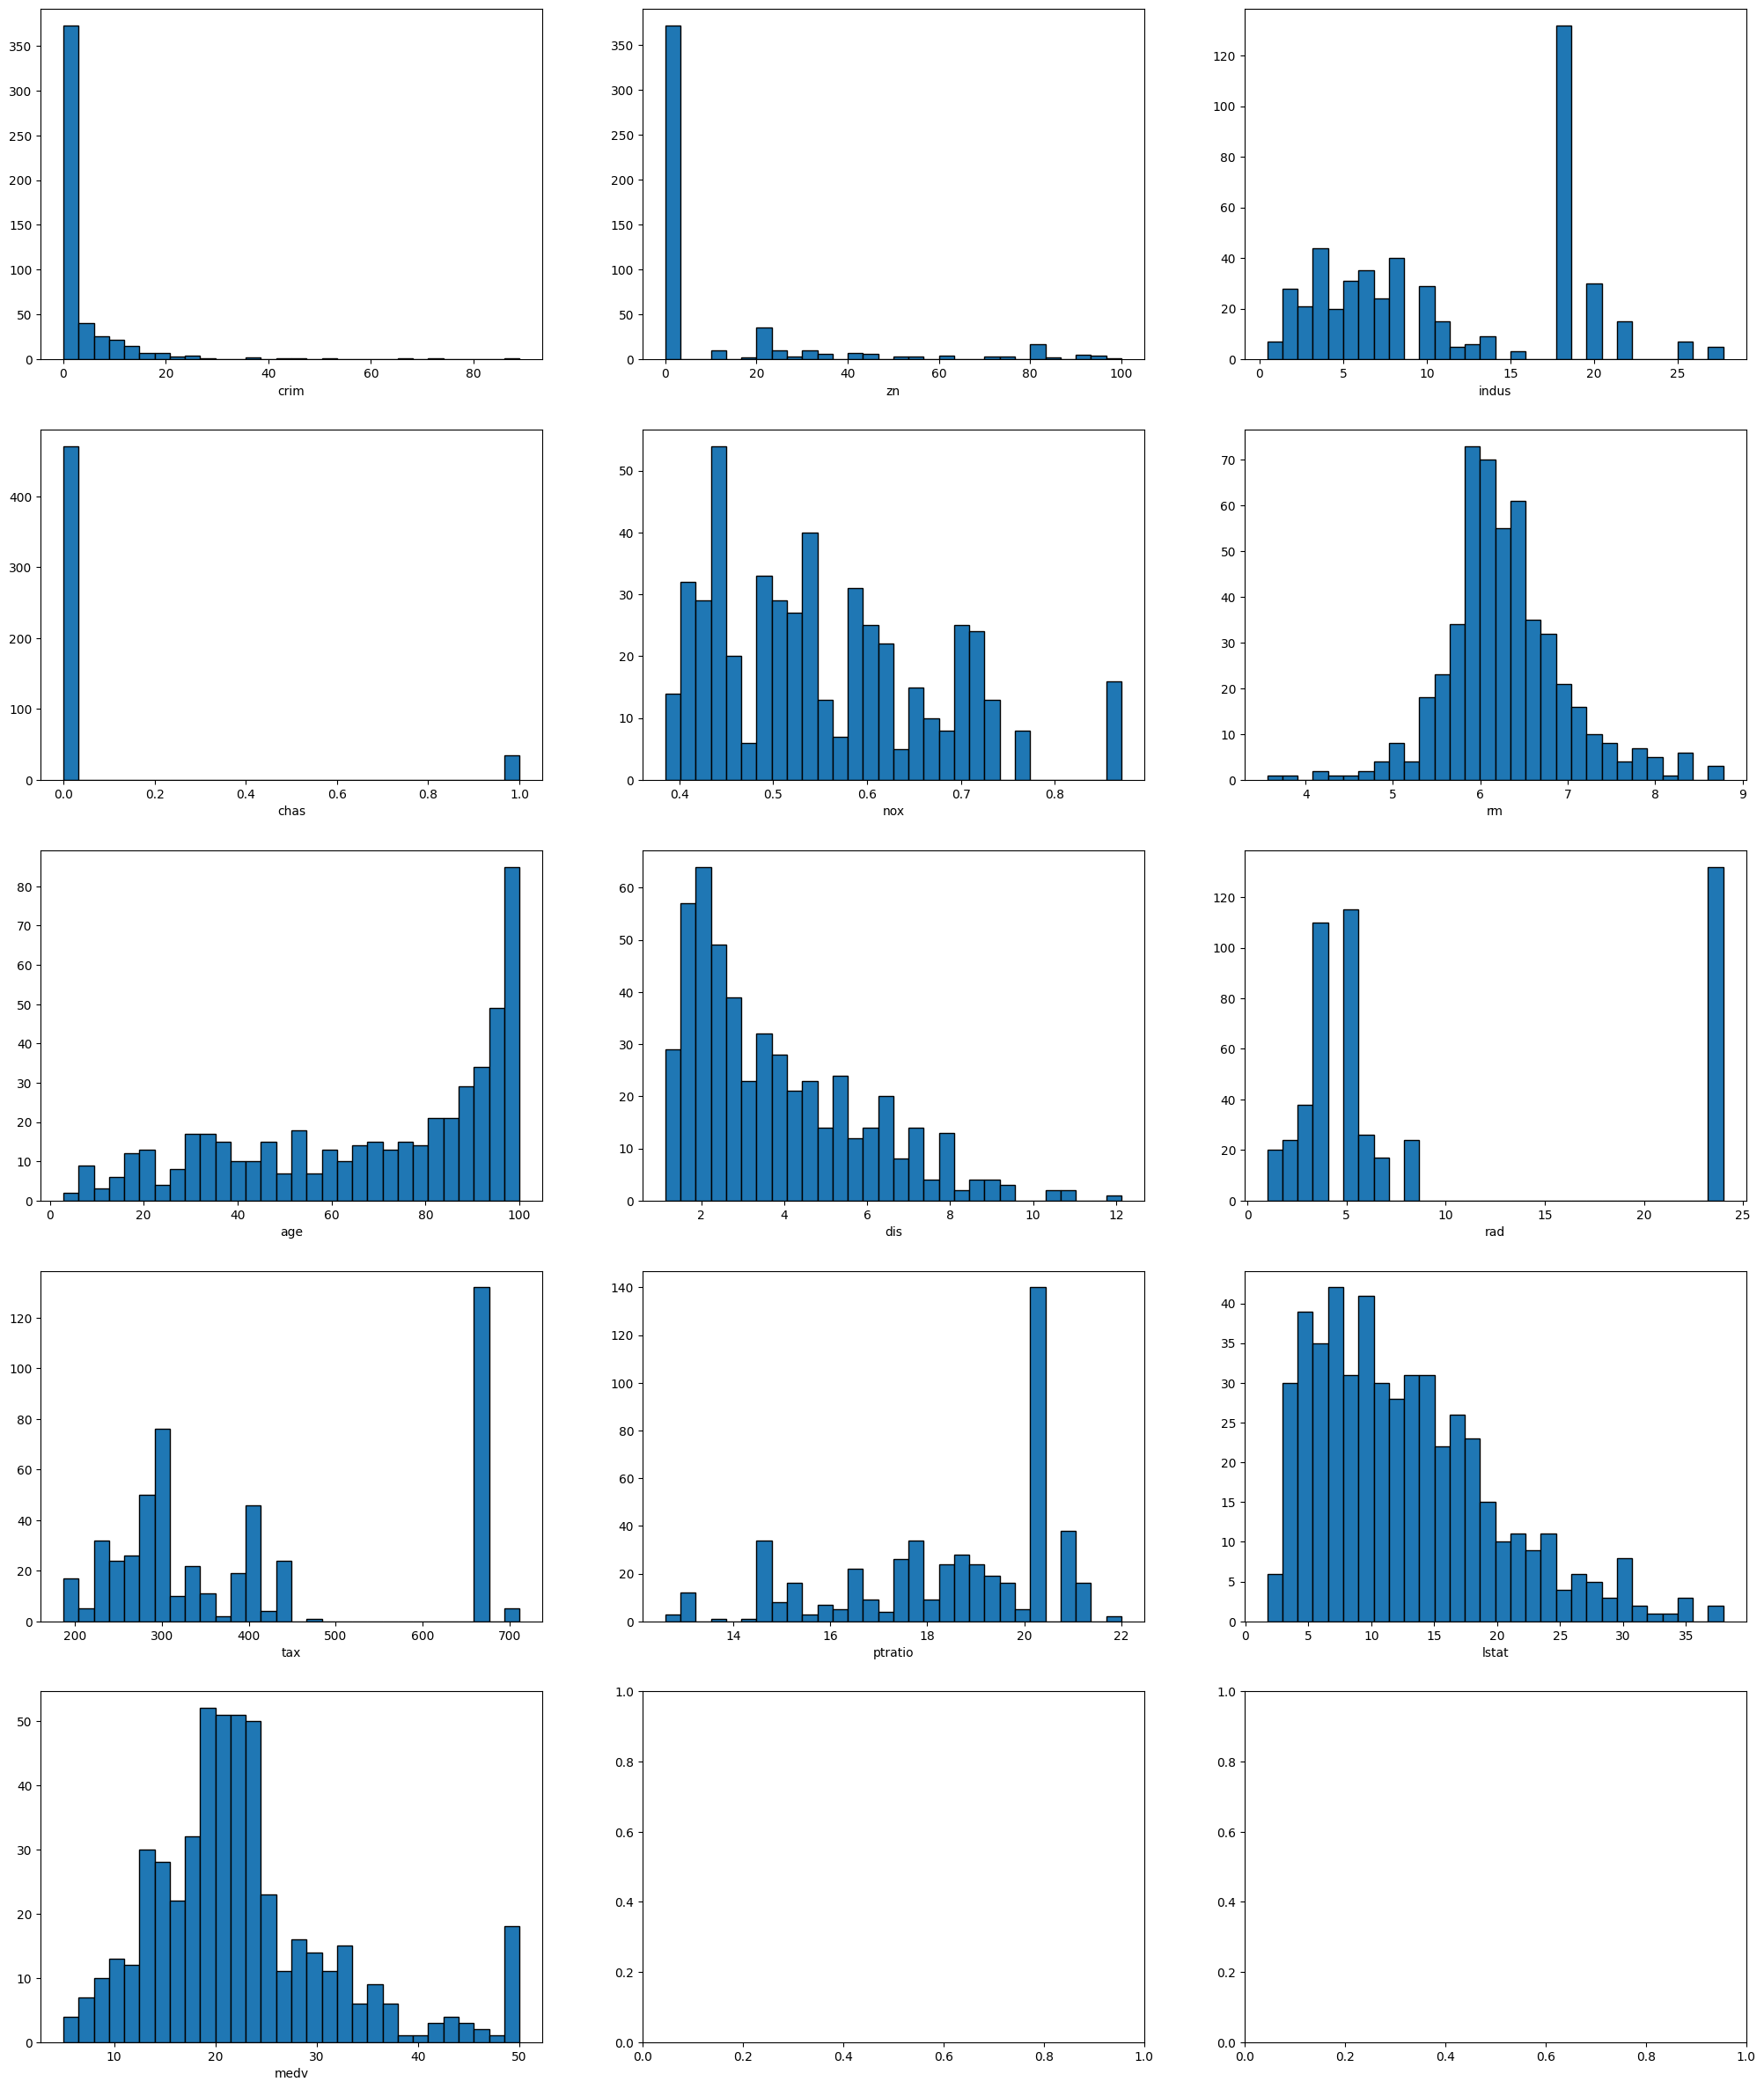

In [41]:
# Initialize the plots before drawing them
nrows = 5
ncols = 3
figsize = (5*nrows, 10*ncols)

fig, axes = subplots(nrows=nrows,
                     ncols=ncols,
                     figsize=figsize)

# Assign a grid location to each index
def range_to_grid(i, nrows, ncols):
    x=[]
    y=[]
    for n in range(nrows*ncols):
        x.append(n // ncols)
        y.append(n % ncols)
        # print(n,x[n],y[n]) # for testing this function
    return x[i],y[i]

# Plot the variables as paired boxplots
for j, col in enumerate(Boston.columns):
    r, c = range_to_grid(j, nrows, ncols)
    ax = axes[r, c]

    ax.hist(Boston[col], bins=30, edgecolor='black')

    ax.set_xlabel(col)

In [42]:
Boston.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,0.543993,-0.468536


## Standardization

In [43]:
scaler = StandardScaler().set_output(transform="pandas")
Boston_std = scaler.fit_transform(Boston)
pd.DataFrame(Boston_std)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,-1.075562,0.159686
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,-0.492439,-0.101524
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,-1.208727,1.324247
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,-1.361517,1.182758
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,-1.026501,1.487503
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,-0.413229,-0.487722,0.115738,-0.272599,0.158124,0.439316,0.018673,-0.625796,-0.982843,-0.803212,1.176466,-0.418147,-0.014454
502,-0.415249,-0.487722,0.115738,-0.272599,0.158124,-0.234548,0.288933,-0.716639,-0.982843,-0.803212,1.176466,-0.500850,-0.210362
503,-0.413447,-0.487722,0.115738,-0.272599,0.158124,0.984960,0.797449,-0.773684,-0.982843,-0.803212,1.176466,-0.983048,0.148802
504,-0.407764,-0.487722,0.115738,-0.272599,0.158124,0.725672,0.736996,-0.668437,-0.982843,-0.803212,1.176466,-0.865302,-0.057989


## PCA

### First we'll conduct PCA on only three of the columns.

In [44]:
subset1 = Boston_std[['age', 'nox', 'ptratio']]

### Notice that `age` and `nox` are highly correlated, but `ptratio` is as not strongly correlated with either of them.

In [45]:
pd.DataFrame(subset1.corr())

,age,nox,ptratio
age,1.000000,0.731470,0.261515
nox,0.731470,1.000000,0.188933
ptratio,0.261515,0.188933,1.000000


### Fit the principal components.

In [46]:
PCA_subset = PCA()
PCA_subset.fit(subset1)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

### When we print the components by each variable, we can see that the first (0th) component is influenced by `age` and `nox` while the second (1st) component is mostly influenced by `ptratio`. 

This is consistent with the correlations that we calculated earlier.

In [47]:
components_subset = pd.DataFrame(PCA_subset.components_, columns=subset1.columns.to_list())
components_subset

,age,nox,ptratio
0,0.670084,0.653978,0.351140
1,-0.193164,-0.303124,0.933168
2,0.716711,-0.693129,-0.076794


### What percent of variance is explained by each component?

In [48]:
PCA_subset.explained_variance_ratio_

array([0.61697612, 0.29483176, 0.08819212])

### Next we'll tranform the original data to the principal components and graph the records along first two components.

In [49]:
PCA_subset_scores = PCA_subset.transform(subset1)

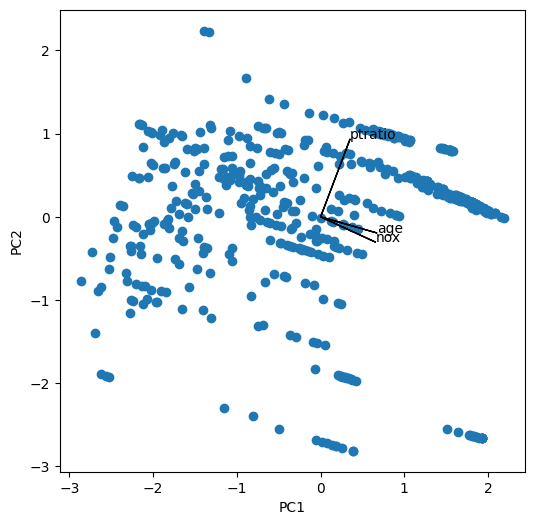

In [50]:
i, j = 0, 1 # which components
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(PCA_subset_scores[:,0], PCA_subset_scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(PCA_subset.components_.shape[1]):
    ax.arrow(0, 0, PCA_subset.components_[i,k], PCA_subset.components_[j,k])
    ax.text(PCA_subset.components_[i,k],
            PCA_subset.components_[j,k],
            subset1.columns[k])

### Now conduct principal components analysis on the entire standardized Boston dataset.

In [51]:
PCA_Boston = PCA()
PCA_Boston.fit(Boston_std)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

### Calculate the components and include the column names

In [52]:
components_Boston = pd.DataFrame(
    PCA_Boston.components_,
    columns=Boston_std.columns
)

### Based on these components, determine which variable has the _most_ influence on the first principal component, and which variable has the _least_ influence on the first principal component. 

Note that the first principal component will appear as component 0

In [ ]:
#fillin 
var_most_influencing_1st_pc = 'indus'
var_least_influencing_1st_pc = 'chas'

## K-means Clustering

### First we'll conduct k-means clustering using only two variables, so that we can graph the results in 2 dimensions.

In [54]:
# create the dataset
subset2 = Boston_std[['rm', 'indus']]

In [55]:
# build the clusters
kmeans1 = KMeans(n_clusters=3,
                random_state=seed,
                n_init=1).fit(subset2)

In [56]:
# record the cluster assignments
cluster_km1 = pd.DataFrame(kmeans1.labels_)
cluster_km1

,0
0,0
1,0
2,0
3,0
4,0
...,...
501,2
502,2
503,2
504,2


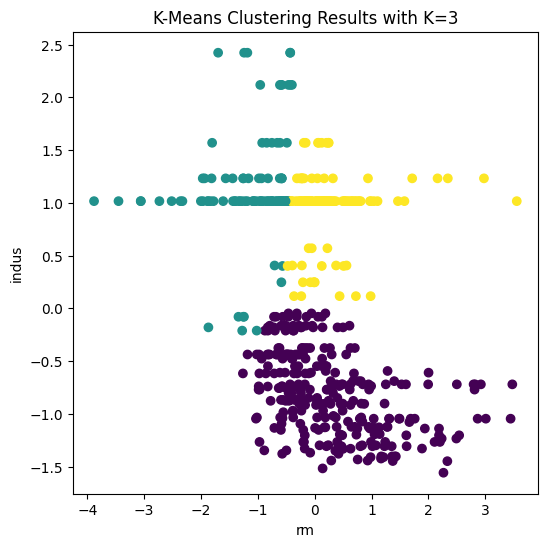

In [57]:
# plot the clusters
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(subset2['rm'], subset2['indus'], c=cluster_km1)
ax.set_title("K-Means Clustering Results with K=3")
ax.set_xlabel('rm')
ax.set_ylabel('indus');

### Let's try this again, but choosing the optimal cluster assignments across 1000 iterations.

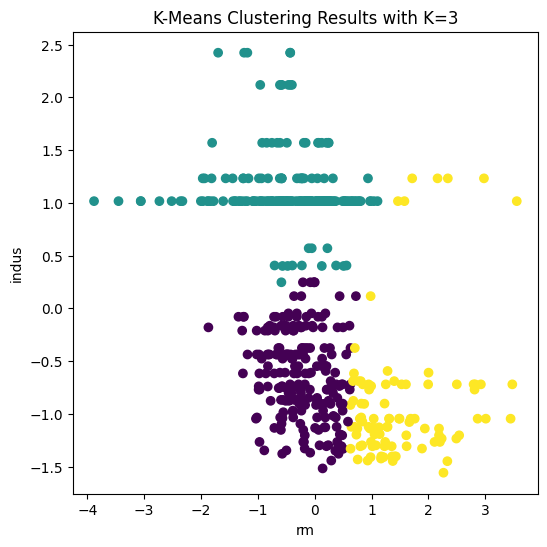

In [58]:
kmeans2 = KMeans(n_clusters=3,
                random_state=seed,
                n_init=1000).fit(subset2)

cluster_km2 = pd.DataFrame(kmeans2.labels_)

fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(subset2['rm'], subset2['indus'], c=cluster_km2)
ax.set_title("K-Means Clustering Results with K=3")
ax.set_xlabel('rm')
ax.set_ylabel('indus');

### Now let's try 4 clusters instead of 3

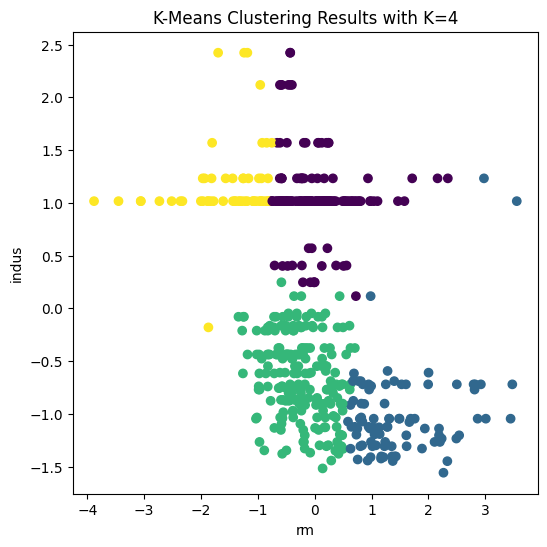

In [59]:
kmeans3 = KMeans(n_clusters=4,
                random_state=seed,
                n_init=1000).fit(subset2)

cluster_km3 = pd.DataFrame(kmeans3.labels_)

fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(subset2['rm'], subset2['indus'], c=cluster_km3)
ax.set_title("K-Means Clustering Results with K=4")
ax.set_xlabel('rm')
ax.set_ylabel('indus');

### In the picture displaying 4 clusters (above), there are several points that are classified into one cluster but seem much closer to the centroid of another cluster. Why is that?

#Because K-means assigns each point based on the exact Euclidean distance to the cluster centroids, not based on which colored group it visually seems closest to. In the plot, the centroids are not shown, so by eye some points can look like they belong to another cluster even though their true distance to their assigned centroid is smaller. Also, K-means is optimizing the overall within-cluster sum of squares for all points at once, so the final grouping can look a little unintuitive for a few boundary points.

### Now run a K-means analysis on the entire standardized Boston dataset (with all variables included). Use 5 clusters, 1000 iterations, and the same seed as prior K-means models.

### Store the model as "kmeans_all" and the cluster assignments as "cluster_km_all"

In [60]:
kmeans_all = KMeans(n_clusters=5, random_state=seed, n_init=1000).fit(Boston_std)

cluster_km_all = pd.DataFrame(kmeans_all.labels_)

### What variable in the Boston dataset is most correlated with the cluster assignments of "kmeans_all"? 

In [61]:
# coding work can go here
cluster_series = cluster_km_all[0]

correlations = Boston_std.corrwith(cluster_series).abs()
correlations.sort_values(ascending=False)

chas       0.583605
zn         0.370743
ptratio    0.096298
indus      0.094326
rad        0.069565
nox        0.066609
crim       0.054033
tax        0.049420
dis        0.044605
medv       0.041837
lstat      0.033676
age        0.025581
rm         0.003007
dtype: float64

In [ ]:
# provide answer here, with variable name inside the quotes
var_most_correlated_w_kmeans = 'chas'

## Hierarchical Clustering

### To better visualize this, let's do a first example on subset of _rows_ of the Boston data. 

In [63]:
# Create a random sample by randomly choosing row indices
random.seed(seed)
index = random.sample(range(Boston_std.shape[0]), 12)

subset3 = Boston_std.iloc[index]
subset3

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
275,-0.409341,1.229060,-0.689681,-0.272599,-0.930305,0.811152,-0.916570,0.224497,-0.637962,-0.916058,-0.395567,-1.355910,1.030385
144,-0.097030,-0.487722,1.231945,-0.272599,2.732346,-1.968357,1.039261,-1.164247,-0.523001,-0.031105,-1.736418,2.332062,-1.168132
105,-0.405084,-0.487722,-0.375976,-0.272599,-0.299707,-0.617781,1.000145,-0.802491,-0.523001,-0.143951,1.130230,0.535034,-0.330083
259,-0.344101,0.370669,-1.045700,-0.272599,0.797361,0.794056,1.117494,-0.848221,-0.523001,-0.856665,-2.522434,-0.806429,0.823594
272,-0.407181,0.370669,-0.609431,-0.272599,-0.783454,0.360960,-0.351157,0.058212,-0.752922,-1.100176,0.066796,-0.690084,0.203221
385,1.535926,-0.487722,1.015999,-0.272599,1.255192,-1.435535,1.049929,-1.126122,1.661245,1.530926,0.806576,2.545127,-1.668784
16,-0.297868,-0.487722,-0.437258,-0.272599,-0.144217,-0.498110,-1.396638,0.334449,-0.637962,-0.601276,1.176466,-0.851284,0.061732
9,-0.400729,0.048772,-0.476654,-0.272599,-0.265154,-0.399808,0.616090,1.329635,-0.523001,-0.577519,-1.505237,0.623344,-0.395385
265,-0.331885,0.370669,-1.045700,-0.272599,0.797361,-1.032357,-0.205359,-0.859725,-0.523001,-0.856665,-2.522434,-0.308812,0.029081
41,-0.405687,-0.487722,-0.616727,-0.272599,-0.921667,0.691480,-2.335437,0.915493,-0.752922,-1.040783,-0.256858,-1.095187,0.442663


### We'll use complete linkage for the clustering

In [64]:
HClust1 = AgglomerativeClustering
hc_comp = HClust1(distance_threshold=0,
                  n_clusters=None,
                  linkage='complete')
hc_comp.fit(subset3)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'complete'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


### We can create a dendrogram, too.

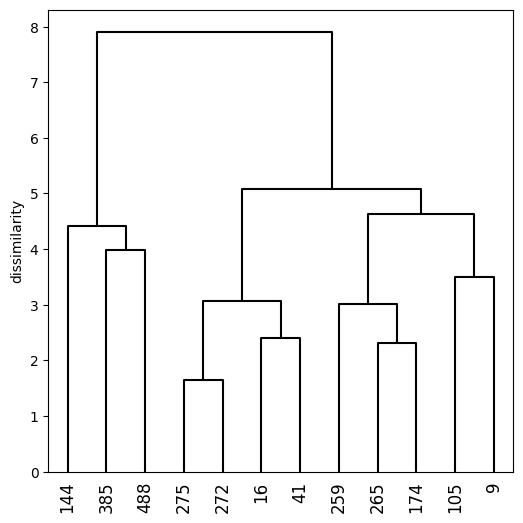

In [65]:
linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=subset3.index,
           color_threshold=-np.inf,
           above_threshold_color='black')
ax.set_ylabel('dissimilarity');

### We can even add color to the dendrogram to distinguish between colors.

Note that we specify a dissimilarity threshold (based on the linkage choice) in this function, rather than a number of clusters.

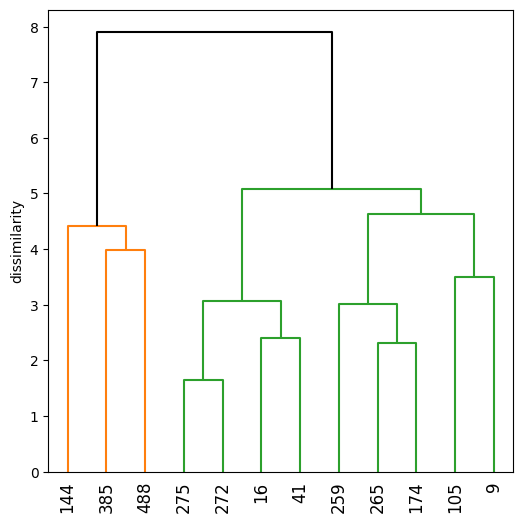

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=subset3.index,
           color_threshold=6, 
           above_threshold_color='black')
ax.set_ylabel('dissimilarity');

### We can also store the cluster assignments.

In [67]:
cluster_h1 = cut_tree(linkage_comp, n_clusters=2)
cluster_h1

array([[0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0]])

### Without changing the underlying model, we can create 3 (or more) clusters instead of 2.

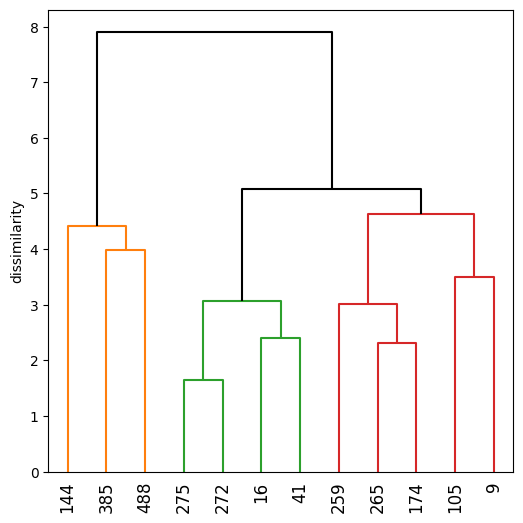

In [68]:
cluster_h2 = cut_tree(linkage_comp, n_clusters=3)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=subset3.index,
           color_threshold=4.75, 
           above_threshold_color='black')
ax.set_ylabel('dissimilarity');

### Let's try doing hierarchical clustering with _average_ linkage.

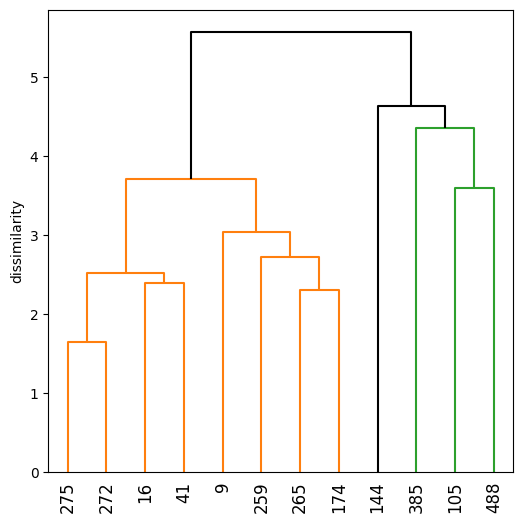

In [69]:
hc_avg = HClust1(distance_threshold=0,
                  n_clusters=None,
                  linkage='average')
hc_avg.fit(subset3)

linkage_avg = compute_linkage(hc_avg)
cluster_h3 = cut_tree(linkage_avg, n_clusters=3)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dendrogram(linkage_avg,
           ax=ax,
           leaf_rotation=90,
           labels=subset3.index,
           color_threshold=4.45, 
           above_threshold_color='black')
ax.set_ylabel('dissimilarity');

### Now run hierarchical clustering with complete linkage on the entire standardized Boston dataset (with all records included). 

### Use 5 clusters and store the cluster assignments as "cluster_h_all"

In [70]:
hc_all = HClust1(distance_threshold=0, n_clusters=None, linkage='complete')
hc_all.fit(Boston_std)

cluster_h_all = cut_tree(compute_linkage(hc_all), n_clusters=5)


### Using the cluster assignments in `cluster_h_all`, how many records of the Boston data are in the largest cluster? How about the smallest cluster? 

In [71]:
# coding work can go here
cluster_counts = pd.Series(cluster_h_all.flatten()).value_counts()

In [72]:
# provide answers here. Do not enter these numbers as strings (i.e., not in quotes)
records_in_largest_cluster = cluster_counts.max()
records_in_smallest_cluster = cluster_counts.min()

### Why did we complete the analysis in this notebook without creating train and test sets?

Because this notebook is doing unsupervised learning. There is no response variable being predicted, so we are not evaluating out-of-sample prediction accuracy the way we would in supervised learning. The goal is to discover structure and groupings in the full dataset, so using all observations is appropriate.